In [ ]:
from pathlib import Path
import joblib

candidates = [
    Path.cwd() / "filtered_pairs.pkl",
    Path.cwd().parent / "filtered_pairs.pkl",
    Path.cwd() / "data" / "processed" / "filtered_pairs.pkl",
]
filtered_pairs_path = next((path for path in candidates if path.exists()), None)
if filtered_pairs_path is None:
    raise FileNotFoundError(
        "filtered_pairs.pkl was not found. Put it in the project root or data/processed/."
    )

filtered_pairs = joblib.load(filtered_pairs_path)
if not filtered_pairs or any(len(pair) != 2 for pair in filtered_pairs):
    raise ValueError("filtered_pairs must contain non-empty (input_text, target_text) pairs.")

print(f"Loaded {len(filtered_pairs):,} conversation pairs from {filtered_pairs_path}")

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/DialoGPT-small")
tokenizer.add_special_tokens({"pad_token": "[PAD]"})
tokenizer.padding_side = "right"

print("pad:", tokenizer.pad_token, tokenizer.pad_token_id)
print("eos:", tokenizer.eos_token, tokenizer.eos_token_id)
assert tokenizer.pad_token_id != tokenizer.eos_token_id

Before: None None <|endoftext|> 50256
After: [PAD] 50257 <|endoftext|> 50256


In [34]:
print(tokenizer.pad_token, tokenizer.pad_token_id)
print(tokenizer.eos_token, tokenizer.eos_token_id)

[PAD] 50257
<|endoftext|> 50256


In [ ]:
combined_text = [
    f"{input_text.strip()} {tokenizer.eos_token} {target_text.strip()} {tokenizer.eos_token}"
    for input_text, target_text in filtered_pairs
]

assert all(text.strip() for text in combined_text)
print(combined_text[0])

In [36]:
len(combined_text)

200050

In [37]:
filtered_pairs[0]

('Can we make this quick?  Roxanne Korrine and Andrew Barrett are having an incredibly horrendous public break- up on the quad.  Again.',
 "Well, I thought we'd start with pronunciation, if that's okay with you.")

In [38]:
combined_text[0]

"Can we make this quick?  Roxanne Korrine and Andrew Barrett are having an incredibly horrendous public break- up on the quad.  Again.<|endoftext|>Well, I thought we'd start with pronunciation, if that's okay with you.<|endoftext|>"

In [ ]:
from datasets import Dataset

raw_dataset = Dataset.from_dict({"text": combined_text})


def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
        padding=False,
    )

In [ ]:
tokenized_dataset = raw_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
)
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

Map:   0%|          | 0/200050 [00:00<?, ? examples/s]

In [41]:
tokenized_dataset = tokenized_dataset.train_test_split(test_size=0.05, seed=42)
train_dataset = tokenized_dataset["train"]
val_dataset = tokenized_dataset["test"]

In [42]:
len(train_dataset), len(val_dataset)

(190047, 10003)

In [ ]:
import torch
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

batch = data_collator([train_dataset[i] for i in range(min(4, len(train_dataset)))])
valid_labels = (batch["labels"] != -100).sum(dim=1)
print("valid label tokens per sample:", valid_labels.tolist())
assert torch.all(valid_labels > 0), "At least one batch sample has no valid labels."

In [44]:
batch = data_collator([train_dataset[i] for i in range(2)])
print(batch.keys())

KeysView({'input_ids': tensor([[ 8205,  6267,    13, 50256,  2202,   262,  6203,   286,   262, 36514,
            11,   262,  1755,   345,  1965,   502,   284, 12479,   345,    13,
           220,   775,  6304,   470,   881,  4697,   621,   484,   389,    13,
         50256, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257, 50257,
         50257, 50257, 50257,

In [ ]:
from transformers import AutoModelForCausalLM, TrainingArguments, Trainer

model = AutoModelForCausalLM.from_pretrained("microsoft/DialoGPT-small")
model.resize_token_embeddings(len(tokenizer))
model.config.pad_token_id = tokenizer.pad_token_id

training_args = TrainingArguments(
    output_dir="./dialogpt_results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=100,
    logging_first_step=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    report_to="none",
)

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

In [ ]:
sample = train_dataset[0]

with torch.no_grad():
    output = model(
        input_ids=sample["input_ids"].unsqueeze(0),
        attention_mask=sample["attention_mask"].unsqueeze(0),
        labels=sample["input_ids"].unsqueeze(0),
    )

print("Initial loss:", output.loss.item())
print("Contains NaN in logits:", torch.isnan(output.logits).any().item())
assert torch.isfinite(output.loss), "The initial loss is not finite."

Loss: tensor(14.8164)
Contains NaN in logits: tensor(False)


In [48]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

In [ ]:
train_result = trainer.train()
trainer.save_model("./dialogpt_results/final")
tokenizer.save_pretrained("./dialogpt_results/final")
print(train_result.metrics)

Epoch,Training Loss,Validation Loss
1,0.000000,nan


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=23756, training_loss=3.570640706558343, metrics={'train_runtime': 1950.9534, 'train_samples_per_second': 97.412, 'train_steps_per_second': 12.177, 'total_flos': 1.2414441701376e+16, 'train_loss': 3.570640706558343, 'epoch': 1.0})

In [50]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch
0.000000,nan,1


{'eval_loss': nan}

Let's inspect some samples from the `val_dataset` to see how the truncation and padding affect the tokenized sequences.

First 5 validation samples (decoded):
Sample 1 (input_ids decoded): He's stubborn as a Stone.<|endoftext|>Hold the splint tighter -- it's almost done.  Go on reading, Ma. This man, Job, he had troubles, didn't he?<|endoftext|>[PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD]
Labels 1: tensor([ 1544,   338, 24444,   355,   257,  8026,    13, 50256, 26807,   262,
         4328,   600, 28619,  1377,   340,   338,  2048,  1760,    13,   220,
         1514,   319,  3555,    11,  6669,    13,   770,   582,    11, 15768,
           11,   339,   550, 14979,    11,  1422,   470,   339,    30, 50256,
         -1

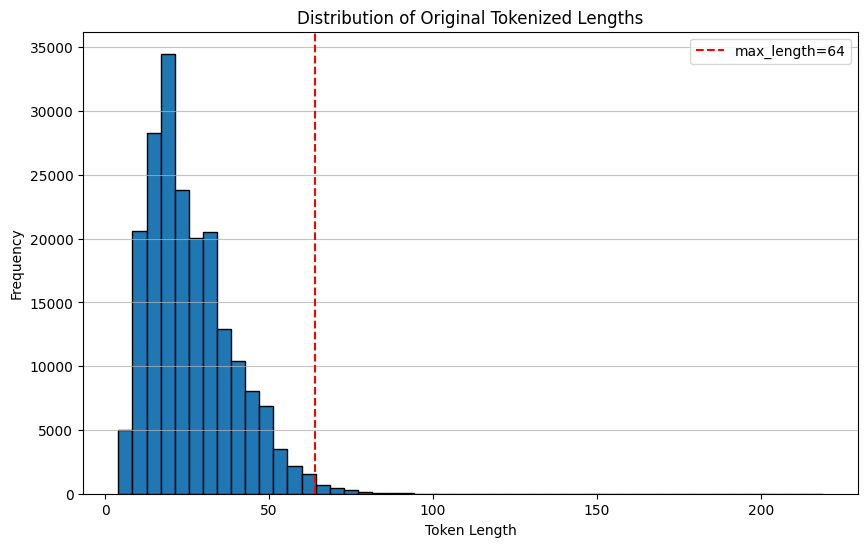

In [51]:
print('First 5 validation samples (decoded):')
for i in range(5):
    sample = val_dataset[i]
    # Pass a single sample through the data collator to see how labels are generated
    collated_batch = data_collator([sample])

    sample_tokens = collated_batch['input_ids'][0]
    decoded_text = tokenizer.decode(sample_tokens, skip_special_tokens=False)
    print(f'Sample {i+1} (input_ids decoded): {decoded_text}')
    # Display the labels from the collated batch
    print(f'Labels {i+1}: {collated_batch["labels"][0]}')
    print('---')

# Let's also check the length distribution of the original combined_text
import matplotlib.pyplot as plt

original_lengths = [len(tokenizer.encode(text)) for text in combined_text]
plt.figure(figsize=(10, 6))
plt.hist(original_lengths, bins=50, edgecolor='black')
plt.title('Distribution of Original Tokenized Lengths')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.axvline(x=64, color='r', linestyle='--', label='max_length=64')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

After inspecting the decoded samples and the length distribution, if a significant portion of your `combined_text` sequences are much longer than 64 tokens, increasing `max_length` in the `tokenize_function` might resolve the `NaN` validation loss. A `max_length` of 64 for concatenated conversational turns can be quite restrictive.

In [52]:
test_inputs = [
    "how are you",
    "what is your name",
    "do you love me",
]

In [53]:
output_model = model.generate(**tokenizer(test_inputs, return_tensors="pt", padding=True))

[transformers] A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_length` (=24) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:2636: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(


In [ ]:
import torch

model.eval()
tokenizer.padding_side = "left"
inputs = tokenizer(
    test_inputs,
    return_tensors="pt",
    padding=True,
    truncation=True,
).to(model.device)

with torch.no_grad():
    output_model = model.generate(
        **inputs,
        max_new_tokens=40,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

new_tokens = output_model[:, inputs["input_ids"].shape[1]:]
for prompt, response in zip(test_inputs, tokenizer.batch_decode(new_tokens, skip_special_tokens=True)):
    print(f"User: {prompt}\nBot: {response.strip()}\n")

'how are you!!!!!!!!!!!!!!!!!!!!'